In [ ]:
#Пример выполнения типового задания:
#Задача: Реализуйте операцию свёртки для сглаживания чёрно-белого изображения.
#Решение:

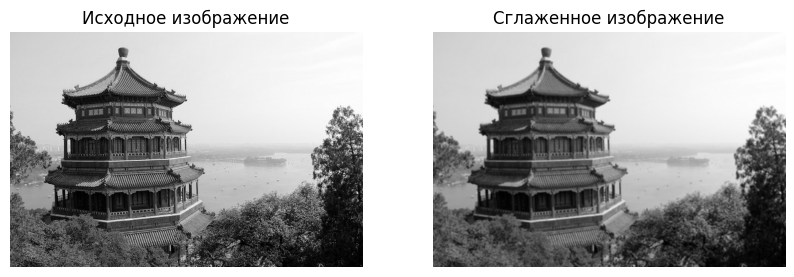

In [1]:
import numpy as np
from scipy.ndimage import convolve
from sklearn.datasets import load_sample_image
import matplotlib.pyplot as plt

# Загрузка изображения
image = load_sample_image("china.jpg")
gray_image = np.mean(image, axis=2)  # Преобразование в градации серого

# Ядро свёртки для сглаживания
kernel = np.ones((3, 3)) / 9

# Применение свёртки
smoothed_image = convolve(gray_image, kernel)

# Визуализация результатов
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Исходное изображение")
plt.imshow(gray_image, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Сглаженное изображение")
plt.imshow(smoothed_image, cmap='gray')
plt.axis('off')
plt.show()

In [ ]:
#Задание 1: Выделение границ на изображении с помощью фильтра Собеля
#Описание: Реализуйте операцию выделения границ на чёрно-белом изображении с помощью фильтра Собеля. Постройте карты вертикальных и горизонтальных границ.

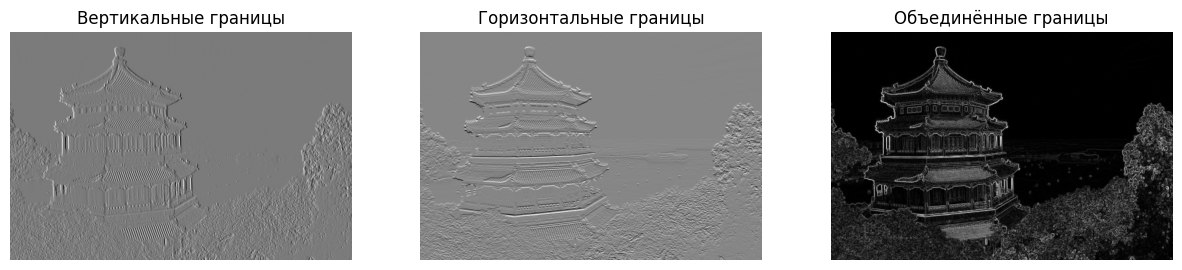

In [2]:
import numpy as np
from scipy.ndimage import convolve
from sklearn.datasets import load_sample_image
import matplotlib.pyplot as plt

# Загрузка изображения
image = load_sample_image("china.jpg")
gray_image = np.mean(image, axis=2)  # Преобразование в градации серого

# Ядра Собеля для вертикальных и горизонтальных границ
sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])

# Применение свёрток
edges_x = convolve(gray_image, sobel_x)
edges_y = convolve(gray_image, sobel_y)

# Объединение результатов
edges = np.sqrt(edges_x**2 + edges_y**2)

# Визуализация результатов
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("Вертикальные границы")
plt.imshow(edges_x, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Горизонтальные границы")
plt.imshow(edges_y, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Объединённые границы")
plt.imshow(edges, cmap='gray')
plt.axis('off')
plt.show()

In [ ]:
#Задание 2: Создание поточечной свёртки
#Описание: Реализуйте поточечную свёртку (Pointwise Convolution) для преобразования числа каналов изображения.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


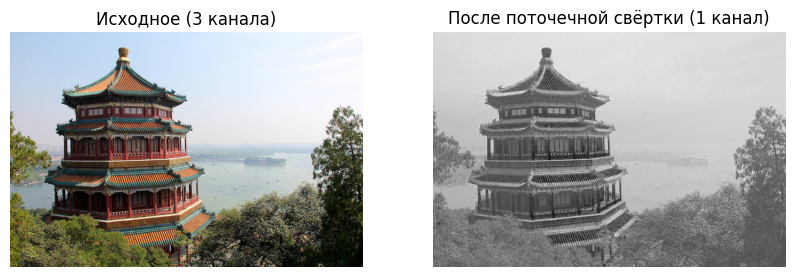

Форма выходного тензора: (1, 427, 640, 1)


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_sample_image
from tensorflow.keras import layers, Model

# Загружаем и подготавливаем изображение
image = load_sample_image("china.jpg")
# Нормализуем и добавляем размерность batch (1, height, width, channels)
input_image = image.astype(np.float32) / 255.0
input_image = np.expand_dims(input_image, axis=0)  # форма (1, H, W, 3)

# Создаём модель поточечной свёртки: уменьшим число каналов с 3 до 1
inputs = layers.Input(shape=(input_image.shape[1], input_image.shape[2], 3))
pointwise_conv = layers.Conv2D(filters=1, kernel_size=1, padding='same')(inputs)
model = Model(inputs=inputs, outputs=pointwise_conv)

# Применяем к изображению
output = model.predict(input_image)  # форма (1, H, W, 1)

# Визуализация
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(input_image[0])
plt.title("Исходное (3 канала)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(output[0, :, :, 0], cmap='gray')
plt.title("После поточечной свёртки (1 канал)")
plt.axis('off')
plt.show()

print(f"Форма выходного тензора: {output.shape}")

In [ ]:
#Задание 3: Реализация групповой свёртки
#Описание: Реализуйте групповую свёртку (Grouped Convolution) с двумя группами для входного изображения.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


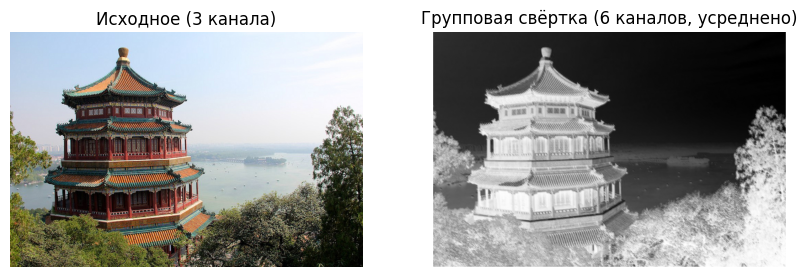

Форма выходного тензора: (1, 427, 640, 6)


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_sample_image
from tensorflow.keras import layers, Model

# Загружаем изображение
image = load_sample_image("china.jpg")
input_image = image.astype(np.float32) / 255.0
# Дублируем каналы, чтобы получить 6 каналов (3 * 2)
input_6ch = np.concatenate([input_image, input_image], axis=-1)
input_6ch = np.expand_dims(input_6ch, axis=0)  # форма (1, H, W, 6)

# Модель: групповая свёртка с 2 группами
inputs = layers.Input(shape=(input_6ch.shape[1], input_6ch.shape[2], 6))
grouped_conv = layers.Conv2D(filters=6, kernel_size=3, padding='same', groups=2)(inputs)
model = Model(inputs=inputs, outputs=grouped_conv)

output = model.predict(input_6ch)  # форма (1, H, W, 6)

# Визуализируем первые 3 канала результата (усреднённо)
output_display = np.mean(output[0], axis=-1)  # усредним по каналам для отображения

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(input_image)  # покажем исходное RGB
plt.title("Исходное (3 канала)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(output_display, cmap='gray')
plt.title("Групповая свёртка (6 каналов, усреднено)")
plt.axis('off')
plt.show()

print(f"Форма выходного тензора: {output.shape}")

In [ ]:
#Задание 4: Реализация поканальной свёртки
#Описание: Реализуйте поканальную свёртку (Depthwise Convolution) для обработки изображения.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


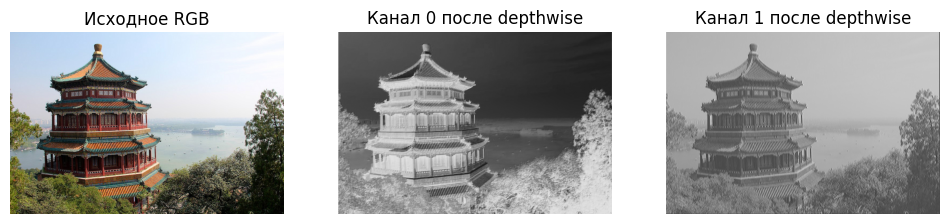

Форма выходного тензора: (1, 427, 640, 3)


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_sample_image
from tensorflow.keras import layers, Model

# Загружаем изображение
image = load_sample_image("china.jpg")
input_image = image.astype(np.float32) / 255.0
input_image = np.expand_dims(input_image, axis=0)  # (1, H, W, 3)

# Поканальная свёртка
inputs = layers.Input(shape=(input_image.shape[1], input_image.shape[2], 3))
depthwise_conv = layers.DepthwiseConv2D(kernel_size=3, padding='same')(inputs)
model = Model(inputs=inputs, outputs=depthwise_conv)

output = model.predict(input_image)  # форма (1, H, W, 3)

# Визуализация: исходное и результат (усредним по каналам для ч/б, либо покажем каждый)
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.imshow(input_image[0])
plt.title("Исходное RGB")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(output[0, :, :, 0], cmap='gray')
plt.title("Канал 0 после depthwise")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(output[0, :, :, 1], cmap='gray')
plt.title("Канал 1 после depthwise")
plt.axis('off')
plt.show()

print(f"Форма выходного тензора: {output.shape}")

In [ ]:
#Задание 5: Комбинация поканальной и поточечной свёрток
#Описание: Реализуйте комбинацию поканальной и поточечной свёрток (Depthwise Separable Convolution).

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


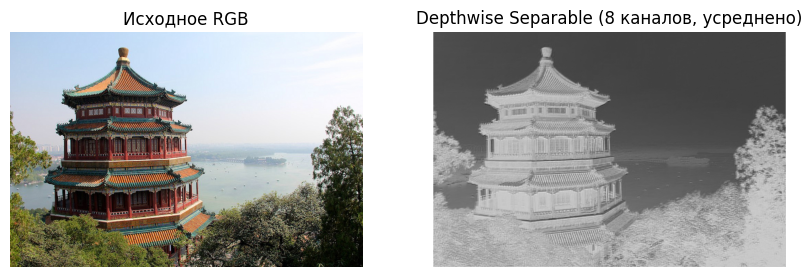

Форма выходного тензора: (1, 427, 640, 8)


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_sample_image
from tensorflow.keras import layers, Model

# Загружаем изображение
image = load_sample_image("china.jpg")
input_image = image.astype(np.float32) / 255.0
input_image = np.expand_dims(input_image, axis=0)  # (1, H, W, 3)

# Модель: Depthwise + Pointwise
inputs = layers.Input(shape=(input_image.shape[1], input_image.shape[2], 3))
x = layers.DepthwiseConv2D(kernel_size=3, padding='same')(inputs)
x = layers.Conv2D(filters=8, kernel_size=1, padding='same')(x)  # увеличим число каналов до 8
model = Model(inputs=inputs, outputs=x)

output = model.predict(input_image)  # форма (1, H, W, 8)

# Визуализируем: усредним по каналам результата
output_display = np.mean(output[0], axis=-1)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(input_image[0])
plt.title("Исходное RGB")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(output_display, cmap='gray')
plt.title("Depthwise Separable (8 каналов, усреднено)")
plt.axis('off')
plt.show()

print(f"Форма выходного тензора: {output.shape}")